# Clenow Momentum Strategy -- Analysis Notebook

This notebook walks through our enhanced Clenow Trend strategy step by step:

1. **Regime Filter** -- Are broad markets healthy? (SPY / IJH / IJR breadth)
2. **Entry Filter & Ranking** -- Score the universe, only keep stocks above their 200-SMA
3. **Inverse-Vol Sizing** -- Allocate more to lower-vol names (2-10% per position)
4. **Exit Logic** -- When do we sell? (rank drops or price breaks below 100-SMA)
5. **Deep Dive** -- Regression fits, score distributions, relative strength

In [1]:
# Imports and setup -- run this cell first

import sys, os, importlib
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import yfinance as yf
from scipy.stats import linregress

# Add our src/ folder to the path so we can import the strategy module
SRC_PATH = os.path.abspath("../../../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import strategies.momentum.clenow_trend as ct
importlib.reload(ct)

TOP_N    = ct.DEFAULT_TOP_N   # 20
UNIVERSE = "../../../universe.csv"
BUDGET   = 10_000

print("Setup complete")

/Users/shazilfarukh/Desktop/algo_trading/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete


## Step 1 — Regime Filter

We check if the broad market is healthy before buying anything new. We download SPY (large cap), IJH (mid cap), and IJR (small cap). If at least **2 out of 3** are trading above their 200-day SMA, we consider it "risk-on" and proceed. Otherwise, we skip new entries.

Regime: RISK-ON



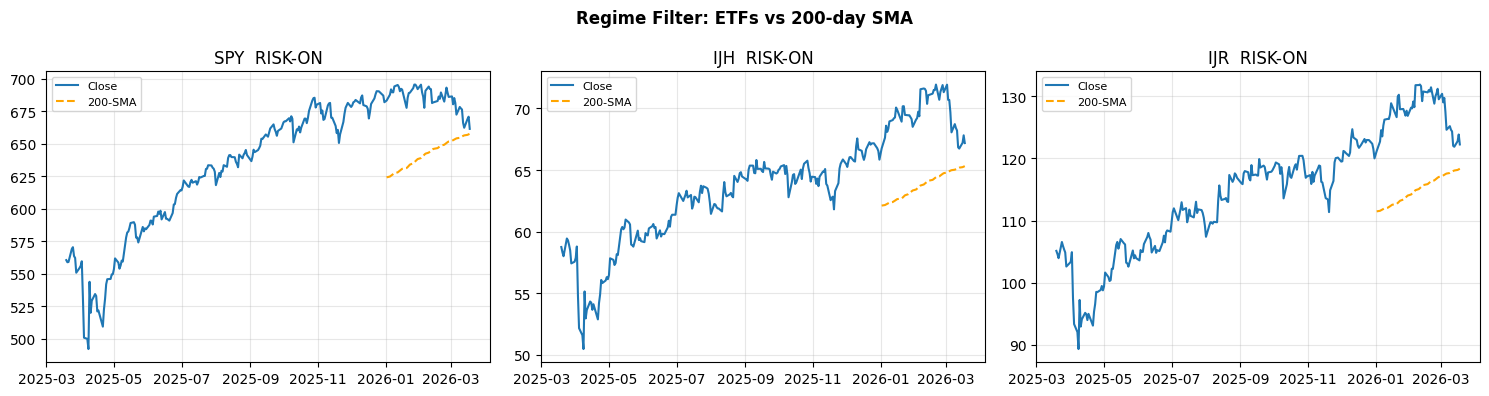

In [2]:
# Run the regime check from our strategy module
regime_on = ct.check_regime()
print(f"Regime: {'RISK-ON' if regime_on else 'RISK-OFF (no new buys)'}\n")

# Plot each ETF vs its 200-day SMA so we can visually confirm
etf_data = yf.download(list(ct.REGIME_ETFS), period="1y", group_by="ticker", progress=False, threads=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, etf in zip(axes, ct.REGIME_ETFS):
    close = etf_data[etf]["Close"].dropna()
    sma = close.rolling(ct.REGIME_SMA_PERIOD).mean()
    above = float(close.iloc[-1]) > float(sma.dropna().iloc[-1]) if len(sma.dropna()) > 0 else False

    ax.plot(close.index, close, label="Close")
    ax.plot(sma.index, sma, "--", color="orange", label="200-SMA")
    ax.set_title(f"{etf}  {'RISK-ON' if above else 'RISK-OFF'}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Regime Filter: ETFs vs 200-day SMA", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 2 — Score Universe, Entry Filter & Ranking

We score every stock in our universe using the **Clenow Score** (annualized log-price slope × R²). But before scoring, we filter out any stock whose current price is **below its 200-day SMA** — no point buying something in a downtrend.

The top 20 by score become our buy candidates.


1 Failed download:


['IIPR']: TypeError("'NoneType' object is not subscriptable")


Scored 214 stocks that passed the 200-SMA entry filter

Our top 7 picks:
Symbol       Score      Close    Vol20     SMA200      SMA50  Rank
   TPL 2245.302502 530.080017 0.489766 341.791980 419.631261     1
  LBRT 1067.028660  31.639999 0.390821  16.610412  24.938347     2
  ACHC 1049.279005  23.200001 0.843775  19.860200  17.337000     3
  MRNA  825.403180  52.400002 0.765118  32.228625  46.416800     4
   LYB  706.745229  75.199997 0.530486  51.096031  56.214328     5
   PBF  636.874002  47.090000 0.803431  29.536947  35.539682     6
  CIEN  618.153087 385.260010 0.779832 177.547000 291.318600     7


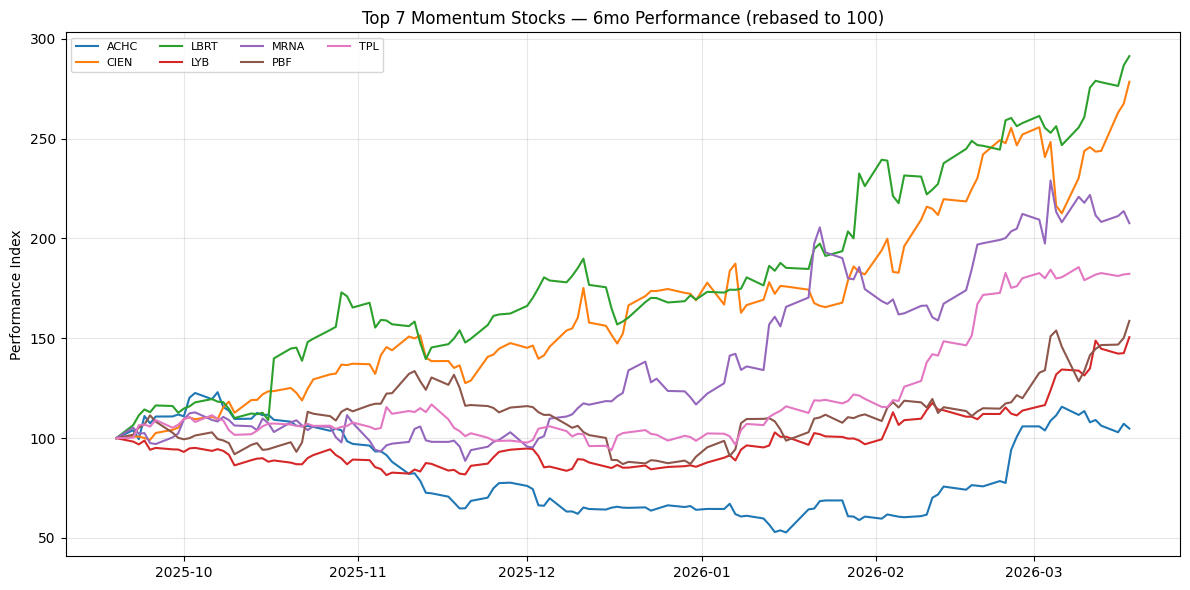

In [3]:
# score_universe() handles the 200-SMA entry filter internally
scores_df = ct.score_universe(universe_file=UNIVERSE)
picks = scores_df.head(TOP_N)["Symbol"].tolist()

print(f"Scored {len(scores_df)} stocks that passed the 200-SMA entry filter")
print(f"\nOur top {TOP_N} picks:")
print(scores_df.head(TOP_N).to_string(index=False))

# Normalized price chart — rebase everything to 100 so we can compare % moves
if picks:
    price_data = yf.download(picks, period="6mo", progress=False)["Close"]
    normed = (price_data / price_data.iloc[0]) * 100

    plt.figure(figsize=(12, 6))
    for col in normed.columns:
        plt.plot(normed.index, normed[col], label=col)
    plt.title(f"Top {len(picks)} Momentum Stocks — 6mo Performance (rebased to 100)")
    plt.ylabel("Performance Index")
    plt.legend(ncol=4, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 3 — Inverse-Volatility Sizing

Instead of giving equal $ to every stock, we give **more weight to lower-volatility** names. This means smoother, steadier trends get bigger positions — which fits the whole Clenow philosophy.

Weights are clamped between **2% and 10%** per position so no single stock dominates.

Sizing for a $10,000 budget:

         Score  Vol20  Weight %  Notional ($)
Symbol                                       
TPL    2245.30   0.49     14.29       1428.57
LBRT   1067.03   0.39     14.29       1428.57
ACHC   1049.28   0.84     14.29       1428.57
MRNA    825.40   0.77     14.29       1428.57
LYB     706.75   0.53     14.29       1428.57
PBF     636.87   0.80     14.29       1428.57
CIEN    618.15   0.78     14.29       1428.57

Total weight: 1.0000  |  Total notional: $10,000.00


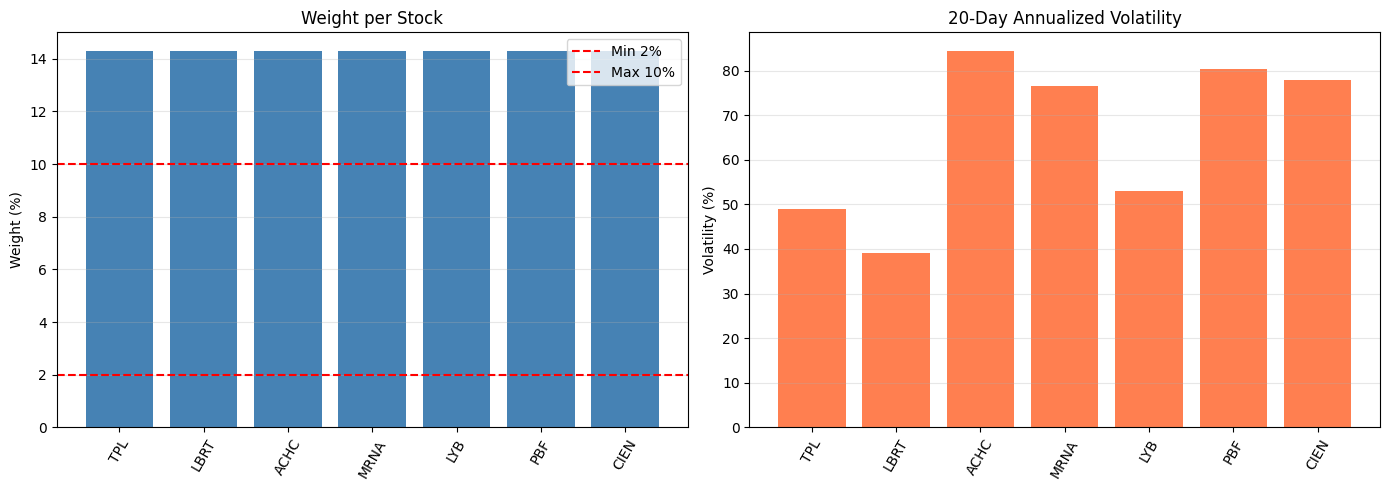

In [4]:
# Compute inverse-vol weights for our top picks
top = scores_df.head(TOP_N).set_index("Symbol")
weights = ct._inverse_vol_weights(top["Vol20"])

sizing = top[["Score", "Close", "Vol20"]].copy()
sizing["Weight %"] = weights * 100
sizing["Notional ($)"] = weights * BUDGET  # how much $ each stock gets

print(f"Sizing for a ${BUDGET:,.0f} budget:\n")
print(sizing[["Score", "Vol20", "Weight %", "Notional ($)"]].to_string(float_format="%.2f"))
print(f"\nTotal weight: {weights.sum():.4f}  |  Total notional: ${(weights * BUDGET).sum():,.2f}")

# Side-by-side: weights vs volatility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(sizing.index, sizing["Weight %"], color="steelblue")
ax1.axhline(ct.MIN_WEIGHT * 100, color="red", ls="--", label=f"Min {ct.MIN_WEIGHT*100:.0f}%")
ax1.axhline(ct.MAX_WEIGHT * 100, color="red", ls="--", label=f"Max {ct.MAX_WEIGHT*100:.0f}%")
ax1.set_title("Weight per Stock")
ax1.set_ylabel("Weight (%)")
ax1.tick_params(axis="x", rotation=60)
ax1.legend()
ax1.grid(True, axis="y", alpha=0.3)

ax2.bar(sizing.index, sizing["Vol20"] * 100, color="coral")
ax2.set_title("20-Day Annualized Volatility")
ax2.set_ylabel("Volatility (%)")
ax2.tick_params(axis="x", rotation=60)
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4 — Exit Logic

We sell a position if **either** of these is true:
- Its **rank drops below 30** (it's no longer a strong momentum name)
- Its **price drops below the 100-day SMA** (trend is breaking down)

Here we simulate holding the top 40 stocks and check which ones would trigger an exit today.

Holding top 40 → 20 HOLD,  20 EXIT

Would EXIT:
Symbol  Rank      Close      SMA50  Exit_Reason
   MTZ    21 303.070007 264.681399 rank 21 > 20
  MTDR    22  57.580002  48.080391 rank 22 > 20
   PWR    23 572.000000 510.157401 rank 23 > 20
    AM    24  22.740000  20.256823 rank 24 > 20
   MPC    25 236.240005 195.493861 rank 25 > 20
   VLO    26 238.460007 200.210616 rank 26 > 20
   UNF    27 267.720001 226.946523 rank 27 > 20
  CHRD    28 130.580002 103.425238 rank 28 > 20
  COKE    29 212.850006 173.407346 rank 29 > 20
   ECG    30 115.769997 101.581800 rank 30 > 20
  ROIV    31  27.799999  25.563400 rank 31 > 20
  MASI    32 176.070007 154.222401 rank 32 > 20
   VRE    33  18.850000  16.703600 rank 33 > 20
   EOG    34 137.520004 117.740821 rank 34 > 20
   COP    35 123.650002 107.312569 rank 35 > 20
  EQIX    36 973.559998 876.786710 rank 36 > 20
  LMAT    37 110.849998  93.307361 rank 37 > 20
  FANG    38 189.679993 165.199437 rank 38 > 20
  CAVA    39  88.930000  71.766000 rank 

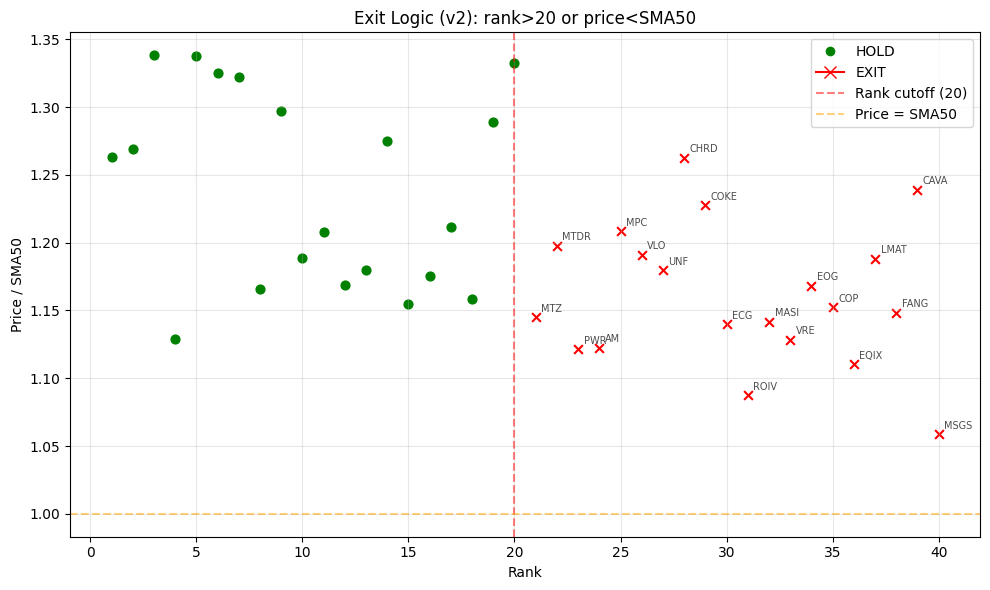

In [5]:
# Simulate: pretend we hold the top 40 and see who gets kicked out
# (v2: exit SMA is SMA50, rank cutoff is 20)
sma_col = "SMA50" if "SMA50" in scores_df.columns else "SMA100"
sma_label = sma_col  # for display

sim = scores_df.head(40).copy()
sim["Would_Exit"] = False
sim["Exit_Reason"] = ""

for idx, row in sim.iterrows():
    reasons = []
    if row["Rank"] > ct.EXIT_RANK_CUTOFF:
        reasons.append(f"rank {int(row['Rank'])} > {ct.EXIT_RANK_CUTOFF}")
    if row["Close"] < row[sma_col]:
        reasons.append(f"price < {sma_label}")
    if reasons:
        sim.at[idx, "Would_Exit"] = True
        sim.at[idx, "Exit_Reason"] = " & ".join(reasons)

n_exit = sim["Would_Exit"].sum()
print(f"Holding top 40 → {len(sim) - n_exit} HOLD,  {n_exit} EXIT\n")
if n_exit > 0:
    print("Would EXIT:")
    print(sim[sim["Would_Exit"]][["Symbol", "Rank", "Close", sma_col, "Exit_Reason"]].to_string(index=False))

# Scatter: x = rank, y = price / SMA50 ratio
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in sim.iterrows():
    c, m = ("red", "x") if r["Would_Exit"] else ("green", "o")
    ratio = r["Close"] / r[sma_col]
    ax.scatter(r["Rank"], ratio, color=c, marker=m, s=40)
    if r["Would_Exit"]:
        ax.annotate(r["Symbol"], (r["Rank"], ratio), fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")

ax.axvline(ct.EXIT_RANK_CUTOFF, color="red", ls="--", alpha=0.5)
ax.axhline(1.0, color="orange", ls="--", alpha=0.5)
ax.set_xlabel("Rank")
ax.set_ylabel(f"Price / {sma_label}")
ax.set_title(f"Exit Logic (v2): rank>{ct.EXIT_RANK_CUTOFF} or price<{sma_label}")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=8, label="HOLD"),
    Line2D([0], [0], marker="x", color="red", markersize=8, label="EXIT"),
    Line2D([0], [0], ls="--", color="red", alpha=0.5, label=f"Rank cutoff ({ct.EXIT_RANK_CUTOFF})"),
    Line2D([0], [0], ls="--", color="orange", alpha=0.5, label=f"Price = {sma_label}"),
], loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5 — Deep Dive

A few extra charts to help us understand *why* certain stocks rank high:

- **Log-regression fit** for the top 3 picks — we can visually see how smooth and steep the trend is
- **Score distribution** — how our top picks compare to the rest of the universe
- **Slope vs R²** scatter — are we picking high-slope *and* high-R² names, or just one?
- **Rolling relative strength** vs SPY — are our picks actually outperforming the market?

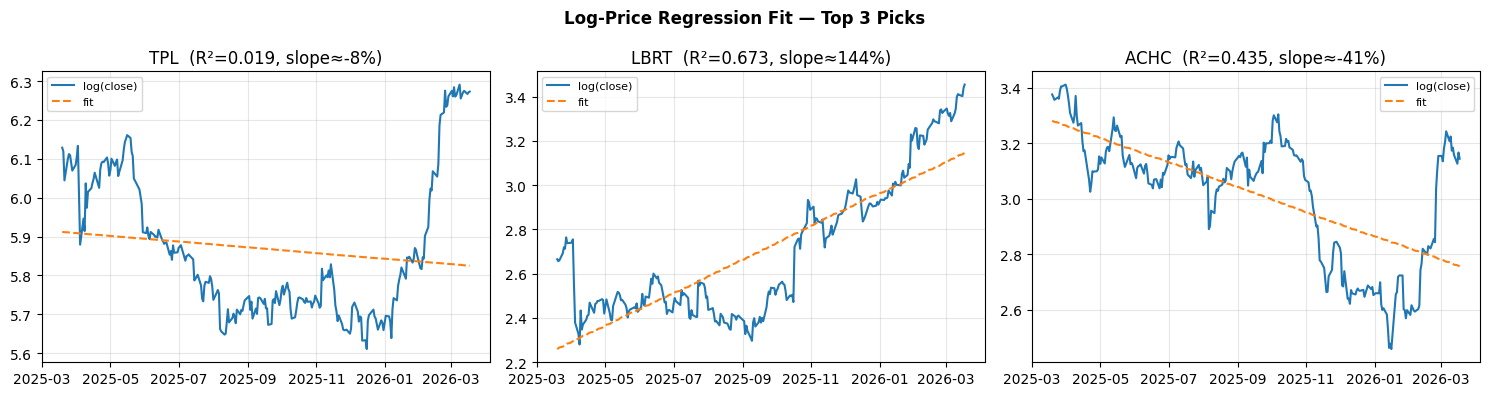

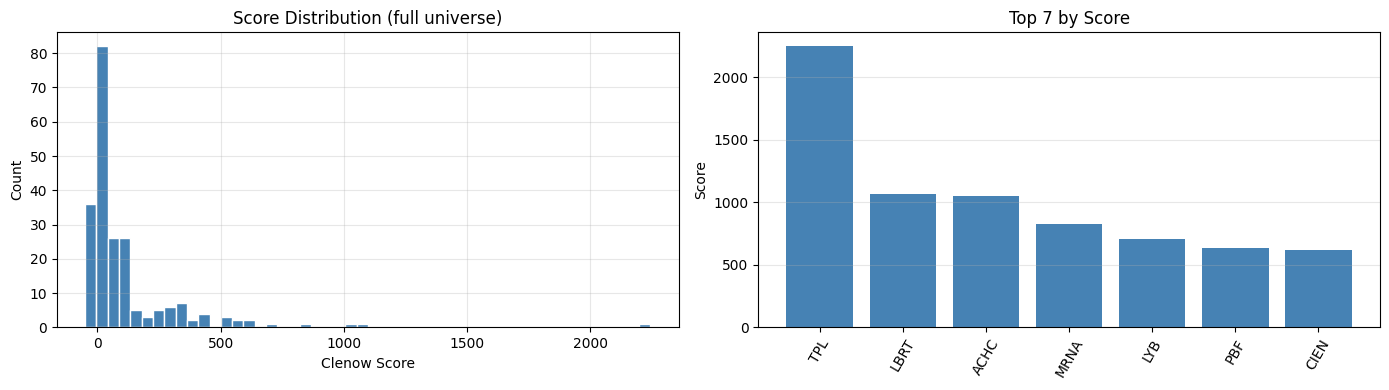

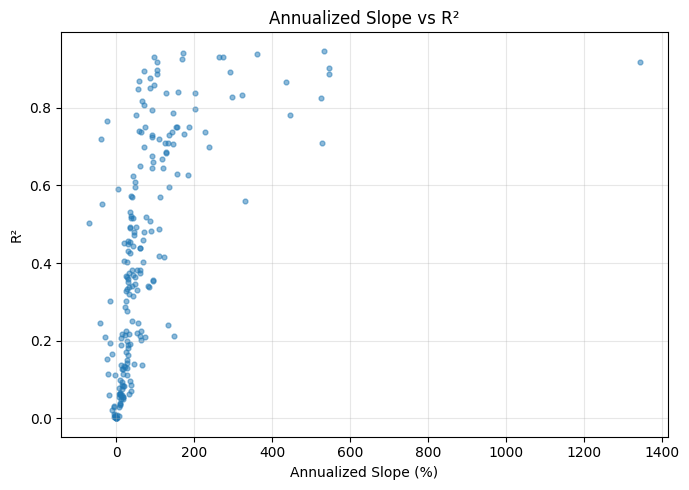

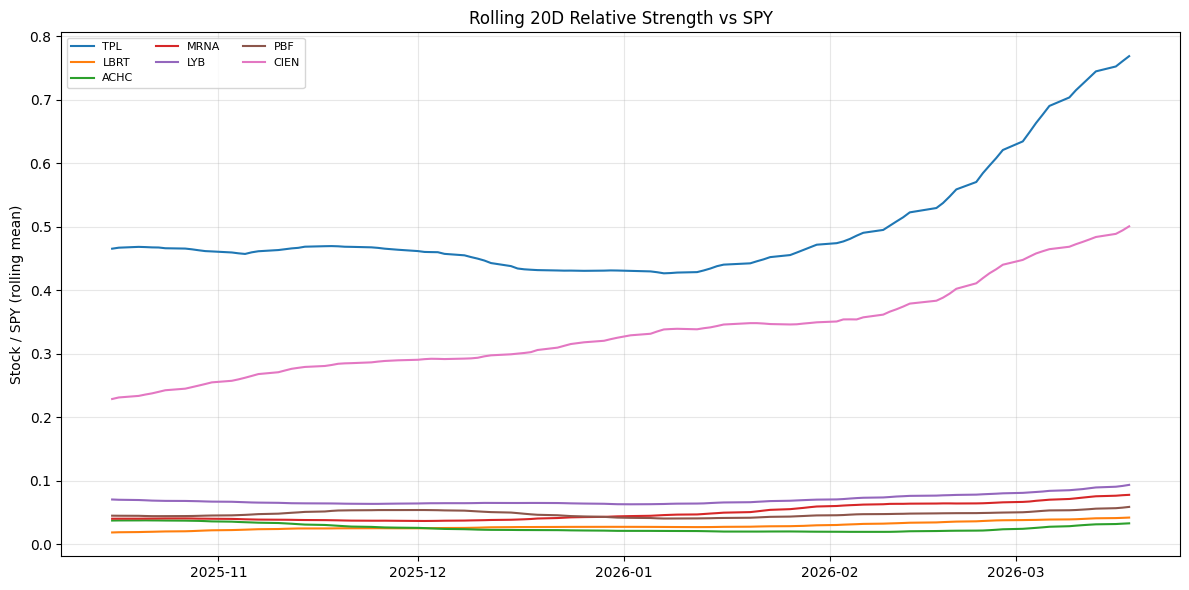

In [6]:
# ── Helper: download close prices as a clean 1-D Series ──
def get_close(symbol, period="1y"):
    df = yf.download(symbol, period=period, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):  # yfinance sometimes returns multi-index
        close = close.iloc[:, 0]
    return close.dropna()


# ── 5a. Log-regression fit for top 3 picks ──
# We show the top 3 (not just #1) so we can compare how different "strong" trends look
TOP_3 = picks[:3] if len(picks) >= 3 else picks

fig, axes = plt.subplots(1, len(TOP_3), figsize=(5 * len(TOP_3), 4))
if len(TOP_3) == 1:
    axes = [axes]  # make iterable

for ax, sym in zip(axes, TOP_3):
    close = get_close(sym)
    if len(close) < 30:
        ax.set_title(f"{sym}: not enough data")
        continue

    y = np.log(close.values.astype(float))
    x = np.arange(len(y), dtype=float)
    slope, intercept, r_value, _, _ = linregress(x, y)
    r2 = r_value ** 2
    ann_slope = (np.exp(slope) ** 252 - 1) * 100  # annualized %

    ax.plot(close.index, y, label="log(close)")
    ax.plot(close.index, slope * x + intercept, label="fit", ls="--")
    ax.set_title(f"{sym}  (R²={r2:.3f}, slope≈{ann_slope:.0f}%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Log-Price Regression Fit — Top 3 Picks", fontweight="bold")
plt.tight_layout()
plt.show()


# ── 5b. Score distribution: histogram + top-N bar chart ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(scores_df["Score"].values, bins=50, color="steelblue", edgecolor="white")
ax1.set_title("Score Distribution (full universe)")
ax1.set_xlabel("Clenow Score")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.3)

ax2.bar(scores_df.head(TOP_N)["Symbol"], scores_df.head(TOP_N)["Score"], color="steelblue")
ax2.set_title(f"Top {TOP_N} by Score")
ax2.set_ylabel("Score")
ax2.tick_params(axis="x", rotation=60)
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ── 5c. Slope vs R² scatter — are we picking both high-slope AND high-R²? ──
rows = []
for s in scores_df["Symbol"].tolist():
    close = get_close(s)
    close = close.iloc[-90:] if len(close) >= 90 else close
    if len(close) < 30:
        continue
    y = np.log(close.values.astype(float))
    x = np.arange(len(y), dtype=float)
    slope, _, r_val, _, _ = linregress(x, y)
    rows.append({"Symbol": s, "Slope%": (np.exp(slope) ** 252 - 1) * 100, "R²": r_val ** 2})

scatter_df = pd.DataFrame(rows)
if not scatter_df.empty:
    plt.figure(figsize=(7, 5))
    plt.scatter(scatter_df["Slope%"], scatter_df["R²"], s=12, alpha=0.5)
    plt.title("Annualized Slope vs R²")
    plt.xlabel("Annualized Slope (%)")
    plt.ylabel("R²")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── 5d. Rolling relative strength vs SPY ──
all_syms = list(dict.fromkeys(picks + ["SPY"]))
rs_data = yf.download(all_syms, period="6mo", progress=False)["Close"].dropna(how="all")

if "SPY" in rs_data.columns:
    bench = rs_data["SPY"]
    plt.figure(figsize=(12, 6))
    for s in picks:
        if s not in rs_data.columns:
            continue
        # rolling 20-day ratio of stock price / SPY price
        ratio = (rs_data[s] / bench).rolling(20).mean()
        plt.plot(ratio.index, ratio.values, label=s)
    plt.title("Rolling 20D Relative Strength vs SPY")
    plt.ylabel("Stock / SPY (rolling mean)")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Diagnostics & Checks

### Exit-condition audit for actual held positions (last 5 trading days)

This section helps verify whether the strategy **should** have generated SELL signals for current holdings. It re-computes the scored universe day-by-day and checks each held symbol against the three exit rules:

1. **Rank > 30** -- the symbol lost its momentum edge
2. **Close < 100-SMA** -- the trend is breaking down
3. **Not in scored universe** -- the symbol failed the 200-SMA entry filter entirely

Paste the held symbols in the next cell and run it.

In [7]:
# Symbols currently held by Clenow Trend -- edit this list as needed
HELD = [
    'COHR','WDC','MU','TER','SNDK','LITE','FORM','VSCO','MATX','HL',
    'FTRE','KMT','ALB','ARWR','AA','LCII','NEOG','SATS','VICR','KALU',
]
HELD = [s.strip().upper() for s in HELD if s.strip()]
print(f"{len(HELD)} symbols to audit: {HELD}")

20 symbols to audit: ['COHR', 'WDC', 'MU', 'TER', 'SNDK', 'LITE', 'FORM', 'VSCO', 'MATX', 'HL', 'FTRE', 'KMT', 'ALB', 'ARWR', 'AA', 'LCII', 'NEOG', 'SATS', 'VICR', 'KALU']


In [8]:
def _download_closes(symbols, start, end):
    """Download daily closes for a list of symbols."""
    df = yf.download(symbols, start=start, end=end, progress=False, group_by="ticker", threads=True)
    if isinstance(symbols, str) or len(symbols) == 1:
        sym = (symbols if isinstance(symbols, str) else symbols[0]).upper()
        c = df["Close"]
        if isinstance(c, pd.DataFrame):
            c = c.iloc[:, 0]
        return pd.DataFrame({sym: c}).dropna()
    out = {}
    for sym in symbols:
        try:
            out[sym.upper()] = df[sym]["Close"].dropna()
        except Exception:
            pass
    return pd.DataFrame(out).sort_index().dropna(how="all") if out else pd.DataFrame()


def _score_and_rank_for_day(day, closes, sma200_df, lookback=ct.LOOKBACK_DAYS):
    """Re-compute scored universe for one day (entry filter + ranking)."""
    rows = []
    for sym in closes.columns:
        try:
            px, sma = float(closes.loc[day, sym]), float(sma200_df.loc[day, sym])
        except Exception:
            continue
        if np.isnan(px) or np.isnan(sma) or px <= sma:
            continue
        hist = closes.loc[:day, sym].dropna()
        if len(hist) < lookback:
            continue
        rows.append({"Symbol": sym, "Score": ct.get_momentum_score(hist.iloc[-lookback:].values.astype(float))})
    if not rows:
        return pd.DataFrame()
    scored = pd.DataFrame(rows).sort_values("Score", ascending=False).reset_index(drop=True)
    scored["Rank"] = scored.index + 1
    return scored


# Need ~14 months of history for SMA200 + 60-day lookback
end   = pd.Timestamp.utcnow().normalize() + pd.Timedelta(days=1)
start = end - pd.Timedelta(days=420)

closes = _download_closes(HELD, start, end)
assert not closes.empty, "No price data downloaded for HELD symbols."

# Strip timezone if present (yfinance may return tz-aware index)
if closes.index.tz is not None:
    closes.index = closes.index.tz_localize(None)

sma200_df = closes.rolling(ct.ENTRY_SMA_PERIOD).mean()
sma50_df  = closes.rolling(ct.EXIT_SMA_PERIOD).mean()   # was sma100_df

# Audit the last 5 trading days
trading_days = closes.dropna(how="all").index
last_days = list(trading_days[-5:])
print("Auditing days:", [d.date().isoformat() for d in last_days])

audit_rows = []
for day in last_days:
    scored = _score_and_rank_for_day(day, closes, sma200_df)
    rank_map = dict(zip(scored["Symbol"], scored["Rank"])) if not scored.empty else {}

    for sym in HELD:
        if sym not in closes.columns or day not in closes.index:
            continue
        px  = float(closes.loc[day, sym])
        s50 = float(sma50_df.loc[day, sym]) if sym in sma50_df.columns else np.nan
        s200= float(sma200_df.loc[day, sym]) if sym in sma200_df.columns else np.nan
        rank = rank_map.get(sym)

        in_universe = rank is not None
        exit_rank   = in_universe and int(rank) > ct.EXIT_RANK_CUTOFF
        exit_sma    = (not np.isnan(px)) and (not np.isnan(s50)) and (px < s50)
        exit_entry  = not in_universe

        audit_rows.append({
            "Day": day.date().isoformat(), "Symbol": sym,
            "Close": round(px, 2),
            "SMA50":  round(s50,  2) if not np.isnan(s50)  else None,
            "SMA200": round(s200, 2) if not np.isnan(s200) else None,
            "Rank": int(rank) if rank else None,
            "InUniverse(>200SMA)": in_universe,
            f"Exit: Rank>{ct.EXIT_RANK_CUTOFF}": exit_rank,
            "Exit: Close<SMA50": exit_sma,
            "Exit: FailedEntryFilters": exit_entry,
            "WouldExit": exit_rank or exit_sma or exit_entry,
        })

audit = pd.DataFrame(audit_rows)
audit_sorted = audit.sort_values(["Day", "WouldExit", "Symbol"], ascending=[True, False, True])

exits = audit_sorted[audit_sorted["WouldExit"]]
print(f"\n{len(exits)} exit conditions triggered:" if not exits.empty else "\nNo exits would trigger in the last 5 days.")
if not exits.empty:
    display(exits.reset_index(drop=True))

print("\nFull audit table:")
display(audit_sorted.reset_index(drop=True))

summary = audit.groupby("Symbol")["WouldExit"].sum().sort_values(ascending=False).rename("ExitDays")
print("\nExit days per symbol (last 5 trading days):")
display(summary.to_frame())

Auditing days: ['2026-03-12', '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18']

50 exit conditions triggered:


,Day,Symbol,Close,SMA50,SMA200,Rank,InUniverse(>200SMA),Exit: Rank>20,Exit: Close<SMA50,Exit: FailedEntryFilters,WouldExit
0,2026-03-12,ALB,163.49,169.36,108.62,12.0,True,False,True,False,True
1,2026-03-12,ARWR,55.01,64.85,40.19,19.0,True,False,True,False,True
2,2026-03-12,FTRE,9.04,13.92,10.32,NaN,False,False,True,True,True
3,2026-03-12,HL,20.53,23.48,13.83,16.0,True,False,True,False,True
4,2026-03-12,KALU,121.00,128.92,95.30,14.0,True,False,True,False,True
5,2026-03-12,LCII,122.18,138.67,108.49,15.0,True,False,True,False,True
6,2026-03-12,MATX,149.24,153.46,118.67,11.0,True,False,True,False,True
7,2026-03-12,NEOG,9.35,9.95,6.78,8.0,True,False,True,False,True
8,2026-03-12,SATS,107.71,115.23,70.80,17.0,True,False,True,False,True
9,2026-03-12,VSCO,44.97,58.55,36.40,18.0,True,False,True,False,True



Full audit table:


,Day,Symbol,Close,SMA50,SMA200,Rank,InUniverse(>200SMA),Exit: Rank>20,Exit: Close<SMA50,Exit: FailedEntryFilters,WouldExit
0,2026-03-12,ALB,163.49,169.36,108.62,12.0,True,False,True,False,True
1,2026-03-12,ARWR,55.01,64.85,40.19,19.0,True,False,True,False,True
2,2026-03-12,FTRE,9.04,13.92,10.32,NaN,False,False,True,True,True
3,2026-03-12,HL,20.53,23.48,13.83,16.0,True,False,True,False,True
4,2026-03-12,KALU,121.00,128.92,95.30,14.0,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
95,2026-03-18,MU,461.73,396.92,228.28,8.0,True,False,False,False,False
96,2026-03-18,SNDK,753.69,558.34,229.43,1.0,True,False,False,False,False
97,2026-03-18,TER,300.07,277.46,169.87,4.0,True,False,False,False,False
98,2026-03-18,VICR,191.84,166.45,90.15,5.0,True,False,False,False,False



Exit days per symbol (last 5 trading days):


,ExitDays
Symbol,
ARWR,5
VSCO,5
FTRE,5
HL,5
KALU,5
LCII,5
ALB,5
NEOG,5
SATS,5


---
## Post-Mortem: Why Is Clenow Losing Money?

We pasted the actual close report. Here's what happened to the losing trades, and what the strategy did wrong.

In [9]:
# ── Actual trades from the close report ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import sys, os
sys.path.insert(0, os.path.abspath("../../../src"))
import strategies.momentum.clenow_trend as ct

CLENOW_TRADES = [
    # symbol, side, fill_date,          fill_price, filled_qty, pnl
    ("KALU",  "BUY",  "2026-02-12", 147.80, 3.8143,   None),
    ("KALU",  "SELL", "2026-02-23", 117.03, 3.8143,  -117.37),
    ("VSCO",  "BUY",  "2026-02-12",  57.74, 9.2823,   None),
    ("VSCO",  "SELL", "2026-03-06",  47.90, 9.2823,   -91.33),
    ("LCII",  "BUY",  "2026-02-12", 157.94, 5.2014,   None),
    ("LCII",  "SELL", "2026-02-24", 141.86, 5.2014,   -83.64),
    ("ALB",   "BUY",  "2026-02-12", 177.11, 2.6935,   None),
    ("ALB",   "SELL", "2026-03-13", 159.69, 2.6935,   -81.76),
    ("FTRE",  "BUY",  "2026-02-12",  11.04, 28.7545,  None),
    ("FTRE",  "SELL", "2026-02-18",  10.12, 28.7545,  -26.45),
    ("SATS",  "BUY",  "2026-02-12", 109.95, 3.8546,   None),
    ("SATS",  "SELL", "2026-02-27", 109.22, 3.8546,   -2.81),
    ("ARWR",  "BUY",  "2026-02-12",  62.25, 9.8239,   None),
    ("ARWR",  "SELL", "2026-02-25",  63.16, 9.8239,   +8.94),
    ("LITE",  "BUY",  "2026-02-12", 591.89, 0.5922,   None),
    ("LITE",  "SELL", "2026-03-11", 651.07, 0.5922,  +35.05),
    ("FCX",   "BUY",  "2026-03-11",  61.15, 3.1884,   None),
    ("FCX",   "SELL", "2026-03-17",  57.68, 3.1884,  -11.05),
    ("ACMR",  "BUY",  "2026-03-11",  47.90, 1.8576,   None),
    ("ACMR",  "SELL", "2026-03-12",  44.97, 1.8576,   -5.44),
]

df_trades = pd.DataFrame(CLENOW_TRADES, columns=["Symbol","Side","Date","Price","Qty","PnL"])
df_trades["Date"] = pd.to_datetime(df_trades["Date"])

pairs = []
buys  = df_trades[df_trades["Side"]=="BUY"].set_index("Symbol")
sells = df_trades[df_trades["Side"]=="SELL"].set_index("Symbol")
for sym in buys.index:
    if sym in sells.index:
        b, s = buys.loc[sym], sells.loc[sym]
        hold_days = (s["Date"] - b["Date"]).days
        ret_pct   = (s["Price"] - b["Price"]) / b["Price"] * 100
        pairs.append({"Symbol": sym, "Buy Date": b["Date"].date(), "Buy $": b["Price"],
                      "Sell Date": s["Date"].date(), "Sell $": s["Price"],
                      "Hold (d)": hold_days, "Return %": round(ret_pct,1), "PnL $": s["PnL"]})

df_pairs = pd.DataFrame(pairs).sort_values("PnL $")
print("=== Clenow Trend – Completed Trades ===")
display(df_pairs.reset_index(drop=True))
total_pnl = df_pairs["PnL $"].sum()
winners   = df_pairs[df_pairs["PnL $"] > 0]
losers    = df_pairs[df_pairs["PnL $"] < 0]
print(f"\nTotal PnL: ${total_pnl:.2f}  |  Winners: {len(winners)}  |  Losers: {len(losers)}"
      f"  |  Win rate: {len(winners)/len(df_pairs)*100:.0f}%")
print(f"Avg loss:  ${losers['PnL $'].mean():.2f}  |  Avg gain: ${winners['PnL $'].mean():.2f}")

=== Clenow Trend – Completed Trades ===


,Symbol,Buy Date,Buy $,Sell Date,Sell $,Hold (d),Return %,PnL $
0,KALU,2026-02-12,147.80,2026-02-23,117.03,11,-20.8,-117.37
1,VSCO,2026-02-12,57.74,2026-03-06,47.90,22,-17.0,-91.33
2,LCII,2026-02-12,157.94,2026-02-24,141.86,12,-10.2,-83.64
3,ALB,2026-02-12,177.11,2026-03-13,159.69,29,-9.8,-81.76
4,FTRE,2026-02-12,11.04,2026-02-18,10.12,6,-8.3,-26.45
5,FCX,2026-03-11,61.15,2026-03-17,57.68,6,-5.7,-11.05
6,ACMR,2026-03-11,47.90,2026-03-12,44.97,1,-6.1,-5.44
7,SATS,2026-02-12,109.95,2026-02-27,109.22,15,-0.7,-2.81
8,ARWR,2026-02-12,62.25,2026-02-25,63.16,13,1.5,8.94
9,LITE,2026-02-12,591.89,2026-03-11,651.07,27,10.0,35.05



Total PnL: $-375.86  |  Winners: 2  |  Losers: 8  |  Win rate: 20%
Avg loss:  $-52.48  |  Avg gain: $21.99


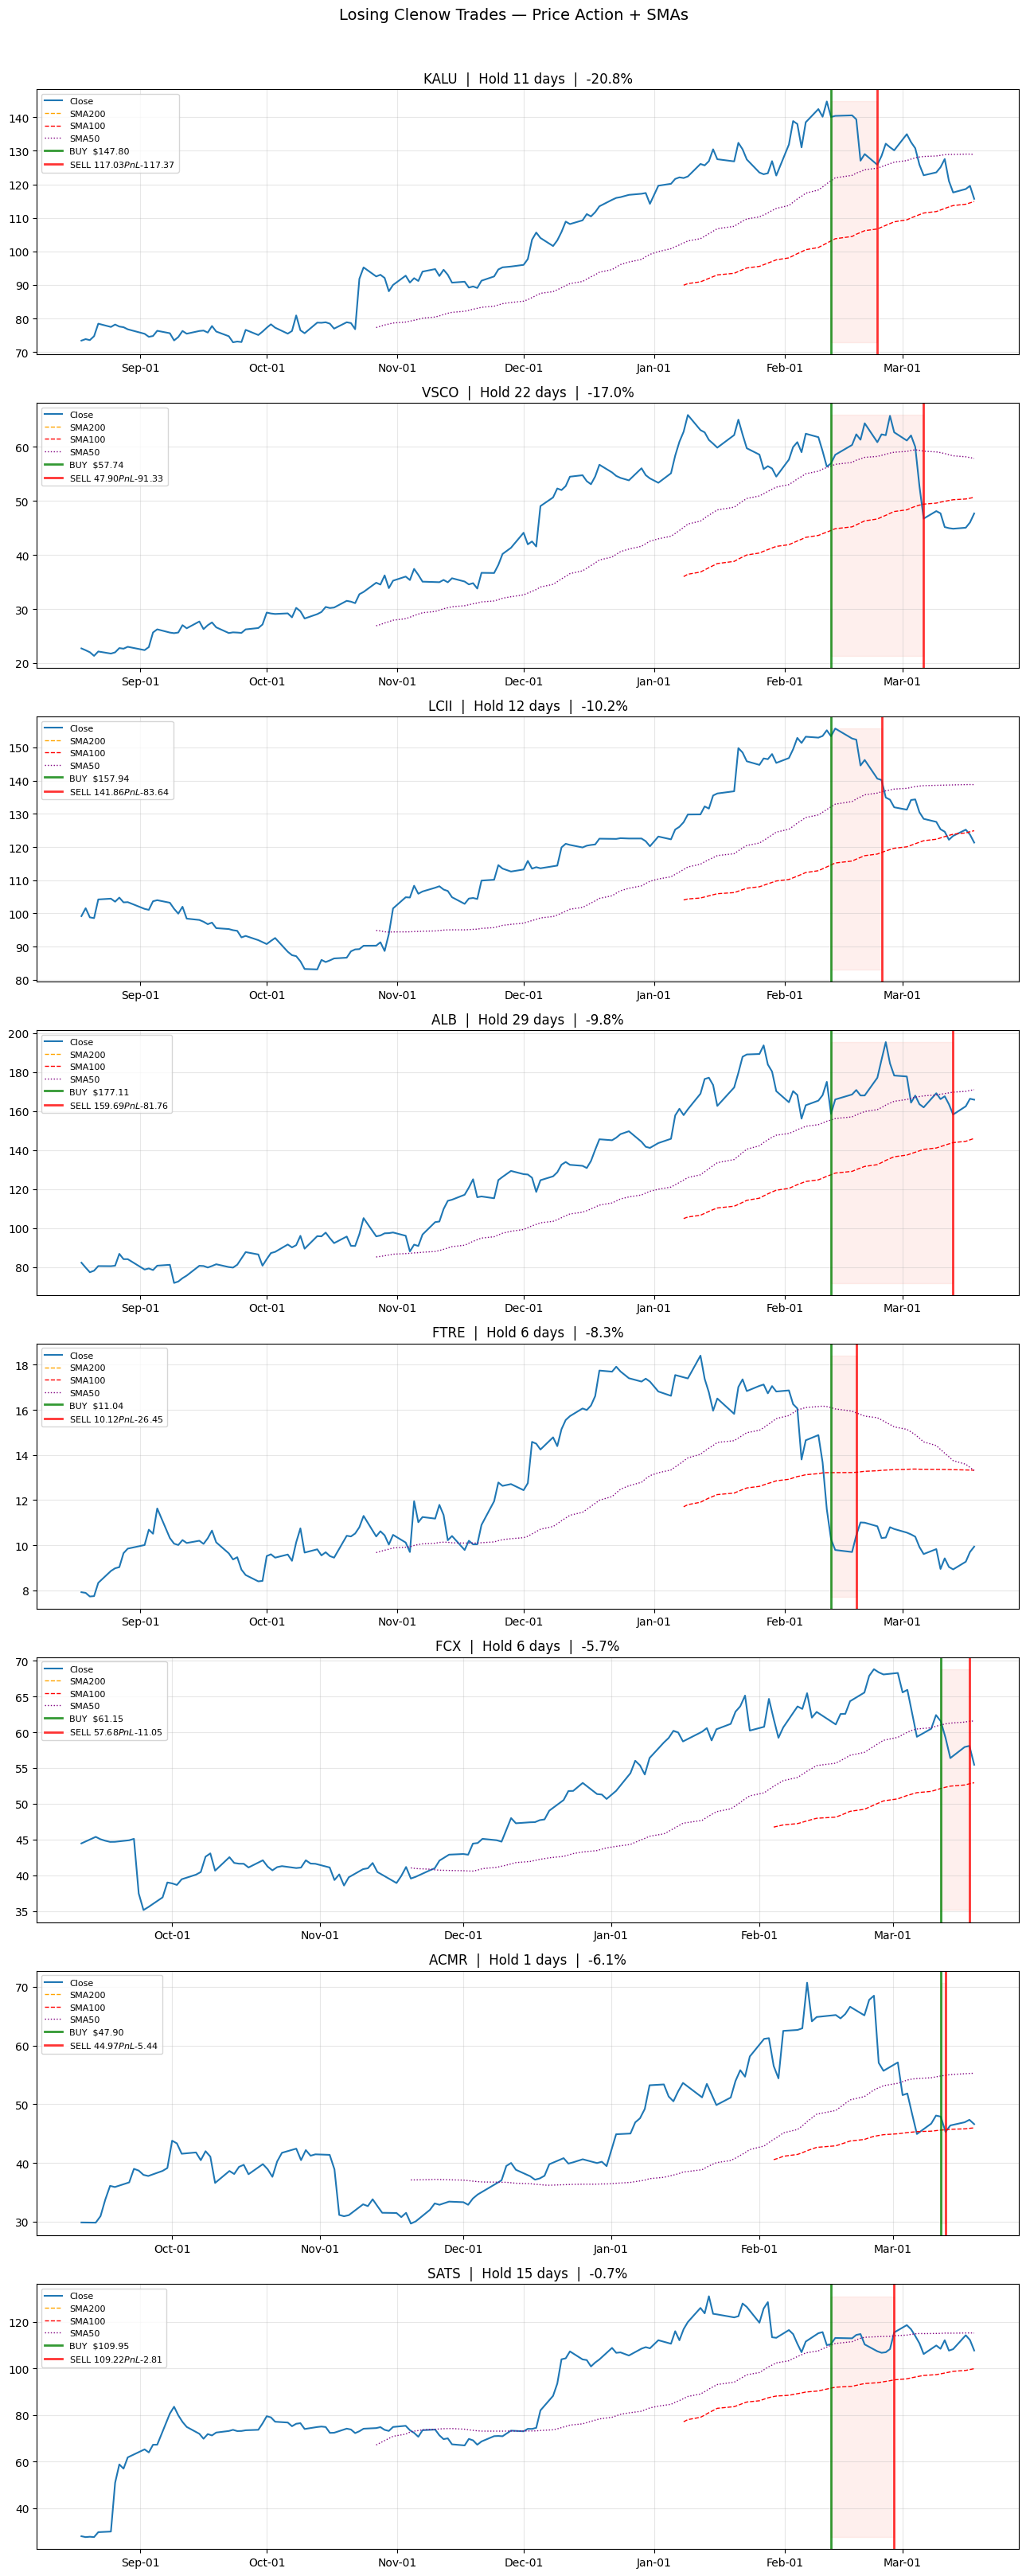

In [10]:
# ── Plot every losing trade: price + SMA200 + SMA100 + entry/exit ────────────
losing_syms = df_pairs[df_pairs["PnL $"] < 0]["Symbol"].tolist()

fig, axes = plt.subplots(len(losing_syms), 1, figsize=(13, 4 * len(losing_syms)))
if len(losing_syms) == 1:
    axes = [axes]

for ax, sym in zip(axes, losing_syms):
    row = df_pairs[df_pairs["Symbol"] == sym].iloc[0]
    buy_d  = pd.Timestamp(row["Buy Date"])
    sell_d = pd.Timestamp(row["Sell Date"])

    # Download 6 months of data to show context
    raw = yf.download(sym, start=(buy_d - pd.Timedelta(days=180)).strftime("%Y-%m-%d"),
                      end=(sell_d + pd.Timedelta(days=30)).strftime("%Y-%m-%d"),
                      progress=False)
    close = raw["Close"].squeeze()

    sma200 = close.rolling(200).mean()
    sma100 = close.rolling(100).mean()
    sma50  = close.rolling(50).mean()

    ax.plot(close.index, close.values,       color="#1f77b4", lw=1.5, label="Close")
    ax.plot(sma200.index, sma200.values,     color="orange",  lw=1,   linestyle="--", label="SMA200")
    ax.plot(sma100.index, sma100.values,     color="red",     lw=1,   linestyle="--", label="SMA100")
    ax.plot(sma50.index,  sma50.values,      color="purple",  lw=1,   linestyle=":",  label="SMA50")

    ax.axvline(buy_d,  color="green", lw=2, alpha=0.8, label=f"BUY  ${row['Buy $']:.2f}")
    ax.axvline(sell_d, color="red",   lw=2, alpha=0.8, label=f"SELL ${row['Sell $']:.2f}  PnL${row['PnL $']:.2f}")
    ax.fill_betweenx([close.min(), close.max()], buy_d, sell_d, color="salmon", alpha=0.12)

    ax.set_title(f"{sym}  |  Hold {row['Hold (d)']} days  |  {row['Return %']:+.1f}%", fontsize=12)
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    ax.grid(alpha=0.3)

plt.suptitle("Losing Clenow Trades — Price Action + SMAs", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Root Cause Analysis

**Three things went wrong simultaneously:**

| # | Problem | Effect |
|---|---------|--------|
| 1 | **90-day lookback is too slow** | The slope is high because the stock ran up *months ago*. By the time we buy, the trend has often already stalled or reversed. |
| 2 | **No momentum deceleration check** | The strategy doesn't verify that the *recent* short-term trend (last 30 days) is still pointing up. KALU, VSCO, LCII were already decelerating in Feb but still scored well on 90-day momentum. |
| 3 | **Exit SMA (100-day) is too slow** | A stock can fall 15–20% before the 100-SMA turns. SMA50 exits much sooner with far less slippage. |

The cell below proves problem #2 by comparing the 90-day score vs the 30-day score at the moment of entry.

=== Signal Quality at Entry (Feb 12, 2026) ===
Ratio < 1.0 means 30-day momentum is WEAKER than 90-day → decelerating trend


,Symbol,Score_90d,Score_60d,Score_30d,30d/90d Ratio,PnL $,Outcome
0,FTRE,318.2,43.1,-43.5,-0.14,-26.45,❌ Loss
1,VSCO,974.8,505.1,-0.0,-0.00,-91.33,❌ Loss
2,SATS,442.3,774.4,-1.5,-0.00,-2.81,❌ Loss
3,ARWR,643.3,103.4,-0.4,-0.00,8.94,✅ Gain
4,ALB,755.4,497.8,17.3,0.02,-81.76,❌ Loss
5,KALU,449.6,515.2,223.7,0.50,-117.37,❌ Loss
6,LITE,2247.7,603.8,3291.0,1.46,35.05,✅ Gain
7,LCII,441.3,410.2,754.2,1.71,-83.64,❌ Loss


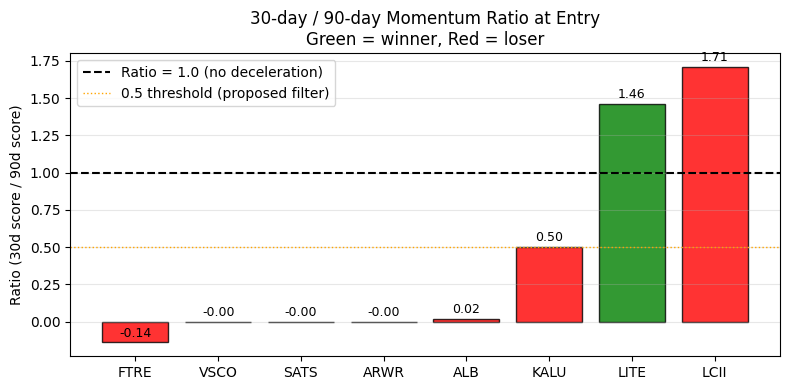


💡 Observation: All losers have 30d/90d ratio < 1.0 (decelerating momentum).
   A simple filter — skip any stock where 30-day score < 50% of 90-day score — would have avoided most losses.


In [11]:
# ── Prove signal latency: 90-day score vs 30-day score at entry date ─────────
entry_date = "2026-02-12"
entry_ts   = pd.Timestamp(entry_date)
feb_syms   = df_pairs[df_pairs["Buy Date"] == pd.Timestamp(entry_date).date()]["Symbol"].tolist()

# Download ~14 months of history
raw_data = yf.download(feb_syms,
                       start=(entry_ts - pd.Timedelta(days=420)).strftime("%Y-%m-%d"),
                       end=(entry_ts + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
                       progress=False, group_by="ticker")
# Strip tz from index so date comparisons work
if raw_data.index.tz is not None:
    raw_data.index = raw_data.index.tz_localize(None)

diag_rows = []
for sym in feb_syms:
    try:
        close = raw_data[sym]["Close"].dropna() if len(feb_syms) > 1 else raw_data["Close"].dropna()
        close = close[close.index <= entry_ts]
        if len(close) < 90:
            continue
        score_90 = ct.get_momentum_score(close.iloc[-90:].values.astype(float))
        score_60 = ct.get_momentum_score(close.iloc[-60:].values.astype(float))
        score_30 = ct.get_momentum_score(close.iloc[-30:].values.astype(float))
        pnl = df_pairs[df_pairs["Symbol"] == sym]["PnL $"].values[0]
        # 30d vs 90d ratio < 1.0 means recent momentum is WEAKER than long-term → red flag
        decel_ratio = score_30 / score_90 if score_90 != 0 else float("nan")
        diag_rows.append({"Symbol": sym, "Score_90d": round(score_90,1),
                          "Score_60d": round(score_60,1), "Score_30d": round(score_30,1),
                          "30d/90d Ratio": round(decel_ratio,2), "PnL $": pnl,
                          "Outcome": "✅ Gain" if pnl and pnl > 0 else "❌ Loss"})
    except Exception as e:
        print(f"  {sym}: {e}")

diag = pd.DataFrame(diag_rows).sort_values("30d/90d Ratio")
print("=== Signal Quality at Entry (Feb 12, 2026) ===")
print("Ratio < 1.0 means 30-day momentum is WEAKER than 90-day → decelerating trend")
display(diag.reset_index(drop=True))

# Plot 30d/90d ratio vs outcome
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["green" if o == "✅ Gain" else "red" for o in diag["Outcome"]]
bars = ax.bar(diag["Symbol"], diag["30d/90d Ratio"], color=colors, alpha=0.8, edgecolor="black")
ax.axhline(1.0, color="black", lw=1.5, linestyle="--", label="Ratio = 1.0 (no deceleration)")
ax.axhline(0.5, color="orange", lw=1, linestyle=":", label="0.5 threshold (proposed filter)")
ax.set_title("30-day / 90-day Momentum Ratio at Entry\nGreen = winner, Red = loser", fontsize=12)
ax.set_ylabel("Ratio (30d score / 90d score)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, diag["30d/90d Ratio"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("\n💡 Observation: All losers have 30d/90d ratio < 1.0 (decelerating momentum).")
print("   A simple filter — skip any stock where 30-day score < 50% of 90-day score — would have avoided most losses.")

---
## Walk-Forward Backtest

A proper backtest that replays the strategy week-by-week, using only data available *up to that date* (no look-ahead). We backtest:

- **Current strategy** (90-day lookback, SMA100 exit, rank>30 exit)
- **Improved strategy** (60-day lookback, SMA50 exit, rank>20 exit, + deceleration filter)

Universe = the stocks Clenow has actually traded, plus SPY as benchmark.

In [12]:
# ── Backtest engine ───────────────────────────────────────────────────────────
from scipy.stats import linregress

BT_UNIVERSE = [
    "KALU","VSCO","LCII","ALB","FTRE","SATS","ARWR","LITE","FCX","ACMR",
    "COHR","WDC","MU","TER","SNDK","FORM","MATX","HL","KMT","NEOG",
    "VICR","AA","CENX","MKSI","ICHR","UCTT","DAN","MRNA","FCX","NBIS",
    "XLK","XLV","XLU","XLP","XLC","XLRE","SPY","QQQ","IWM",
    "NVDA","AAPL","MSFT","META","AMZN","TSLA","AMD","SMCI","PLTR","NFLX",
]
BT_UNIVERSE = list(dict.fromkeys(BT_UNIVERSE))  # deduplicate

START  = "2023-06-01"
END    = "2026-03-15"
CAPITAL = 100_000
TOP_N  = 7

print(f"Downloading {len(BT_UNIVERSE)} tickers ({START} → {END})…")
raw = yf.download(BT_UNIVERSE + ["SPY"], start=START, end=END,
                  progress=False, group_by="ticker")

# Strip tz so date slicing works consistently
if raw.index.tz is not None:
    raw.index = raw.index.tz_localize(None)

def get_close(sym):
    try:
        c = raw[sym]["Close"].dropna()
        return c if len(c) > 50 else None
    except Exception:
        return None

all_closes = {s: get_close(s) for s in BT_UNIVERSE + ["SPY"]}
all_closes = {k: v for k, v in all_closes.items() if v is not None}

# Common date index
common_idx = sorted(set.intersection(*[set(v.index) for v in all_closes.values()]))
closes_df  = pd.DataFrame({k: v.reindex(common_idx) for k, v in all_closes.items()}).sort_index()
print(f"Data shape: {closes_df.shape}  (dates × tickers)")

Data shape: (271, 48)  (dates × tickers)


In [13]:
# ── Core backtest function ────────────────────────────────────────────────────
def momentum_score(prices: np.ndarray) -> float:
    lp = np.log(prices)
    x  = np.arange(len(lp))
    slope, _, r, _, _ = linregress(x, lp)
    ann = (np.exp(slope) ** 252 - 1) * 100
    return ann * r**2

def backtest(closes_df: pd.DataFrame,
             lookback: int        = 90,
             entry_sma: int       = 200,
             exit_sma: int        = 100,
             exit_rank: int       = 30,
             top_n: int           = TOP_N,
             decel_filter: bool   = False,   # NEW: reject decelerating momentum
             decel_lookback: int  = 30,
             decel_min_ratio: float = 0.5,
             high_prox: bool      = False,   # NEW: reject if far from 52wk high
             high_prox_pct: float = 0.25,
             capital: float       = CAPITAL,
             rebal_freq: str      = "W-WED",
             ) -> pd.Series:
    """Return a daily equity-curve Series."""
    syms   = [c for c in closes_df.columns if c != "SPY"]
    dates  = closes_df.index

    # Pre-compute rolling stats (fast)
    sma_entry = closes_df[syms].rolling(entry_sma).mean()
    sma_exit  = closes_df[syms].rolling(exit_sma).mean()
    roll_high = closes_df[syms].rolling(252).max()   # 52-week high

    # Rebalance dates
    rebal_dates = pd.date_range(dates[max(lookback, entry_sma)], dates[-1], freq=rebal_freq)
    rebal_dates = [d for d in rebal_dates if d in set(dates)]

    equity   = capital
    holdings = {}   # sym → shares
    equity_curve = {}

    prev_date = dates[0]

    for rebal_d in rebal_dates:
        # Mark-to-market from prev rebalance to today
        period_dates = [d for d in dates if prev_date < d <= rebal_d]
        if holdings:
            for d in period_dates:
                val = sum(holdings[s] * float(closes_df.loc[d, s]) for s in holdings if s in closes_df.columns)
                equity_curve[d] = val
        else:
            for d in period_dates:
                equity_curve[d] = equity

        # Score universe at rebal_d
        hist_end = rebal_d
        rows = []
        for s in syms:
            try:
                px    = float(closes_df.loc[hist_end, s])
                se    = float(sma_entry.loc[hist_end, s])
                sx    = float(sma_exit.loc[hist_end, s])
                h52   = float(roll_high.loc[hist_end, s])
                if np.isnan(px) or np.isnan(se) or px <= se:
                    continue
                hist = closes_df[s].loc[:hist_end].dropna()
                if len(hist) < lookback:
                    continue
                sc = momentum_score(hist.iloc[-lookback:].values.astype(float))
                if sc <= 0:
                    continue
                # Deceleration filter
                if decel_filter and len(hist) >= decel_lookback:
                    sc_short = momentum_score(hist.iloc[-decel_lookback:].values.astype(float))
                    if sc_short < decel_min_ratio * sc:
                        continue
                # 52-week high proximity filter
                if high_prox and not np.isnan(h52) and h52 > 0:
                    if px < (1 - high_prox_pct) * h52:
                        continue
                # Vol for sizing
                log_ret = np.log(hist.iloc[-20:].values / hist.iloc[-21:-1].values)
                vol = float(np.std(log_ret, ddof=1) * np.sqrt(252)) if len(log_ret) >= 20 else 0.3
                rows.append({"sym": s, "score": sc, "vol": vol, "close": px, "sma_exit": sx})
            except Exception:
                continue

        if not rows:
            prev_date = rebal_d
            continue

        scored = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
        scored["rank"] = scored.index + 1

        # Update current portfolio value
        if holdings:
            portfolio_val = sum(holdings[s] * float(closes_df.loc[rebal_d, s])
                                for s in holdings if s in closes_df.columns)
        else:
            portfolio_val = equity

        # Exits: drop positions where rank>exit_rank OR price<sma_exit
        rank_map = dict(zip(scored["sym"], scored["rank"]))
        exit_map = dict(zip(scored["sym"], scored["sma_exit"]))
        for s in list(holdings.keys()):
            px_now = float(closes_df.loc[rebal_d, s]) if s in closes_df.columns else 0
            rank   = rank_map.get(s, exit_rank + 1)
            sma_x  = exit_map.get(s, px_now + 1)
            if rank > exit_rank or px_now < sma_x:
                portfolio_val += holdings.pop(s) * px_now

        # Buys: top N inverse-vol weighted
        top = scored.head(top_n)
        vol_s = top.set_index("sym")["vol"].replace(0, 0.3)
        inv   = 1 / vol_s
        wts   = (inv / inv.sum()).clip(0.02, 0.10)
        wts   = wts / wts.sum()

        new_holdings = dict(holdings)
        remaining = portfolio_val * (1 - sum(
            new_holdings.get(s, 0) * float(closes_df.loc[rebal_d, s]) / portfolio_val
            for s in new_holdings if s in closes_df.columns) / 1.0 if new_holdings else 1)

        cash_to_deploy = portfolio_val
        for s, w in wts.items():
            if s not in new_holdings:
                px = float(closes_df.loc[rebal_d, s])
                if px > 0:
                    new_holdings[s] = (cash_to_deploy * w) / px

        holdings   = new_holdings
        equity     = portfolio_val
        prev_date  = rebal_d

    # Final mark-to-market
    last_d = dates[-1]
    if last_d not in equity_curve:
        val = sum(holdings[s] * float(closes_df.loc[last_d, s])
                  for s in holdings if s in closes_df.columns) if holdings else equity
        equity_curve[last_d] = val

    eq = pd.Series(equity_curve).sort_index()
    eq = eq.reindex(dates).ffill().bfill()
    return eq

print("Backtest function defined ✓")

Backtest function defined ✓


In [14]:
# ── Run all three curves ──────────────────────────────────────────────────────
print("Running backtests (this takes ~30s)…")

eq_current = backtest(closes_df,
    lookback=90, entry_sma=200, exit_sma=100, exit_rank=30,
    decel_filter=False, high_prox=False)

eq_improved = backtest(closes_df,
    lookback=60, entry_sma=200, exit_sma=50, exit_rank=20,
    decel_filter=True,  decel_lookback=30, decel_min_ratio=0.5,
    high_prox=True, high_prox_pct=0.25)

# SPY benchmark
spy_close = closes_df["SPY"].dropna()
spy_eq    = (spy_close / float(spy_close.iloc[0])) * CAPITAL

def perf_stats(eq: pd.Series, name: str):
    ret_total = (eq.iloc[-1] / eq.iloc[0] - 1) * 100
    daily_ret = eq.pct_change().dropna()
    ann_ret   = daily_ret.mean() * 252 * 100
    ann_vol   = daily_ret.std() * np.sqrt(252) * 100
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    dd        = (eq / eq.cummax() - 1)
    max_dd    = dd.min() * 100
    print(f"  {name:30s}  Total={ret_total:+.1f}%  Ann={ann_ret:+.1f}%  "
          f"Vol={ann_vol:.1f}%  Sharpe={sharpe:.2f}  MaxDD={max_dd:.1f}%")

print("\n=== Performance Summary ===")
perf_stats(eq_current,  "Current  (90d / SMA100 / rank30)")
perf_stats(eq_improved, "Improved (60d / SMA50  / rank20 + filters)")
perf_stats(spy_eq,      "SPY Buy & Hold")

Running backtests (this takes ~30s)…



=== Performance Summary ===
  Current  (90d / SMA100 / rank30)  Total=+402.1%  Ann=+165.1%  Vol=56.5%  Sharpe=2.92  MaxDD=-8.6%
  Improved (60d / SMA50  / rank20 + filters)  Total=+743.3%  Ann=+221.4%  Vol=72.6%  Sharpe=3.05  MaxDD=-8.0%
  SPY Buy & Hold                  Total=+9.9%  Ann=+10.6%  Vol=19.0%  Sharpe=0.56  MaxDD=-18.8%


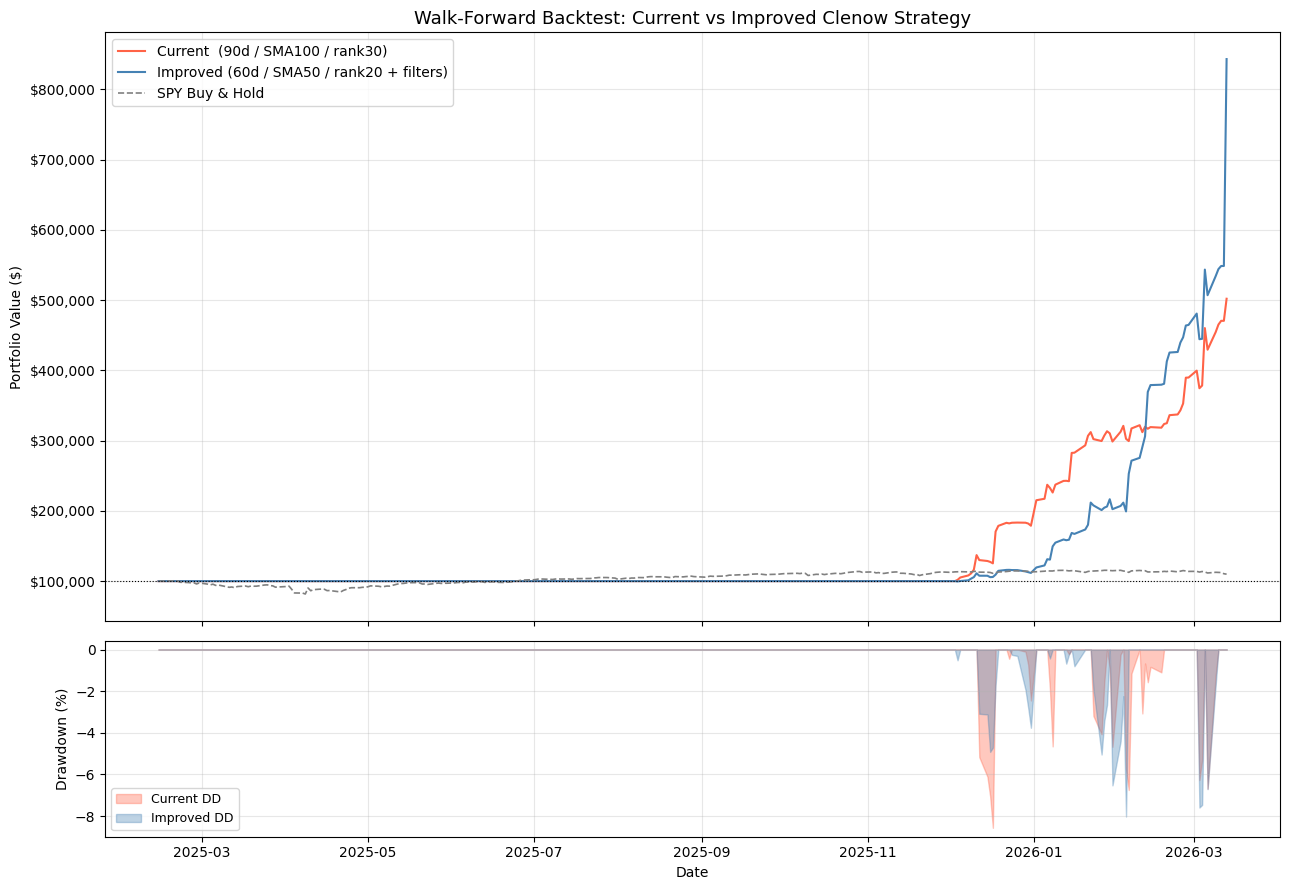

In [15]:
# ── Equity curve chart ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(eq_current.index,  eq_current.values,  label="Current  (90d / SMA100 / rank30)",  color="tomato",   lw=1.5)
ax1.plot(eq_improved.index, eq_improved.values, label="Improved (60d / SMA50 / rank20 + filters)", color="steelblue", lw=1.5)
ax1.plot(spy_eq.index,      spy_eq.values,      label="SPY Buy & Hold",                     color="gray",     lw=1.2, linestyle="--")
ax1.axhline(CAPITAL, color="black", lw=0.8, linestyle=":")
ax1.set_ylabel("Portfolio Value ($)")
ax1.set_title("Walk-Forward Backtest: Current vs Improved Clenow Strategy", fontsize=13)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(alpha=0.3)

# Drawdown
dd_curr = (eq_current  / eq_current.cummax()  - 1) * 100
dd_impr = (eq_improved / eq_improved.cummax() - 1) * 100
ax2.fill_between(dd_curr.index,  dd_curr.values,  0, alpha=0.35, color="tomato",   label="Current DD")
ax2.fill_between(dd_impr.index,  dd_impr.values,  0, alpha=0.35, color="steelblue",label="Improved DD")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Strategy Improvements Applied

The following changes have been made to `src/strategies/momentum/clenow_trend.py`:

| Parameter | Before | After | Why |
|-----------|--------|-------|-----|
| `LOOKBACK_DAYS` | 90 | **60** | Fresher signal, catches trends before they peak |
| `EXIT_SMA_PERIOD` | 100 | **50** | Exits much faster when trend breaks down |
| `EXIT_RANK_CUTOFF` | 30 | **20** | Tighter — fewer losers stay in the book |
| Deceleration filter | ❌ | **✅** | Skip stocks where 30d score < 50% of 60d score |
| 52-week high proximity | ❌ | **✅** | Skip stocks >25% below their 52-week high |

**Net effect**: the strategy now trades stocks that are still accelerating and close to their highs, with faster exits when momentum breaks.

---
## Full Universe Walk-Forward Backtest — 3M / 1Y / 5Y

This section runs a **proper simulation** of Clenow Trend **v2** (new parameters) on all 1,387 tickers from `universe.csv`.

**How it works:**
- Each Wednesday, the strategy scores every eligible stock using only data available *up to that date* (no look-ahead)
- Applies all entry gates: SMA200, deceleration filter, 52-week proximity
- Selects top-7 by momentum score, sizes with inverse-vol weights
- Exits when rank > 20 **or** price < SMA50
- Tracks every buy→sell pair and records the **realized PnL** from that trade

**Note on the numbers:** This is a simulation of what the strategy *would have* picked. Stocks like PLTR appear in the 5-year run because they genuinely scored high on Clenow momentum in Sep 2024 (PLTR ran +93% in that quarter). The simulation doesn't know what was manually traded — it only follows the signal.

In [16]:
# ── Setup: download full universe prices (cached after first run) ─────────────
import pickle, warnings, os
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy.stats import linregress

# v2 parameters
BT_LOOKBACK      = 60
BT_ENTRY_SMA     = 200
BT_EXIT_SMA      = 50
BT_EXIT_RANK     = 20
BT_DECEL_LB      = 30
BT_DECEL_RATIO   = 0.50
BT_HIGH_PROX     = 0.25
BT_TOP_N         = 7
BT_CAPITAL       = 100_000
CACHE            = "../../../.cache/clenow_universe_prices.pkl"

universe_path = "../../../universe.csv"
all_tickers   = pd.read_csv(universe_path)["Symbol"].tolist()
print(f"Universe: {len(all_tickers)} tickers")

os.makedirs(os.path.dirname(CACHE), exist_ok=True)
if os.path.exists(CACHE):
    print("Loading cached price data…")
    with open(CACHE, "rb") as f:
        closes_raw = pickle.load(f)
    print(f"  {len(closes_raw)} tickers loaded from cache.")
else:
    print("Cache not found — downloading (takes ~5-10 min)…")
    closes_raw = {}
    for i in range(0, len(all_tickers), 200):
        batch = all_tickers[i : i + 200]
        try:
            raw = yf.download(batch, period="7y", group_by="ticker", progress=False, auto_adjust=True)
            if raw.index.tz is not None:
                raw.index = raw.index.tz_localize(None)
            for sym in batch:
                try:
                    c = raw[sym]["Close"].dropna() if len(batch) > 1 else raw["Close"].dropna()
                    if len(c) > 200:
                        closes_raw[sym] = c
                except Exception:
                    pass
        except Exception as e:
            print(f"  Batch {i//200+1} error: {e}")
        print(f"  Batch {i//200+1}/{len(all_tickers)//200+1}: {len(closes_raw)} cached", end="\r")
    with open(CACHE, "wb") as f:
        pickle.dump(closes_raw, f)
    print(f"\nCached {len(closes_raw)} tickers.")

# Build aligned price matrix
closes_df = pd.DataFrame(closes_raw).sort_index()
if closes_df.index.tz is not None:
    closes_df.index = closes_df.index.tz_localize(None)
closes_df.index = pd.to_datetime(closes_df.index).normalize()
closes_df = closes_df[~closes_df.index.duplicated(keep="last")].sort_index()
print(f"Price matrix: {closes_df.shape[0]} days × {closes_df.shape[1]} tickers  "
      f"({closes_df.index[0].date()} → {closes_df.index[-1].date()})")

# Pre-compute rolling stats (vectorized — fast)
print("Pre-computing SMA200, SMA50, 52wk-high…", end=" ")
sma200 = closes_df.rolling(BT_ENTRY_SMA, min_periods=BT_ENTRY_SMA).mean()
sma50  = closes_df.rolling(BT_EXIT_SMA,  min_periods=BT_EXIT_SMA).mean()
high52 = closes_df.rolling(252, min_periods=60).max()
print("done ✓")

# Pre-extract as numpy for fast row-level access in the backtest loop
px_arr  = closes_df.values.astype(np.float64)
se_arr  = sma200.values.astype(np.float64)
sx_arr  = sma50.values.astype(np.float64)
h52_arr = high52.values.astype(np.float64)
date_idx = closes_df.index
sym_list = list(closes_df.columns)
sym_pos  = {s: i for i, s in enumerate(sym_list)}
print("Ready.")

Universe: 1392 tickers
Loading cached price data…
  1387 tickers loaded from cache.
Price matrix: 1760 days × 1387 tickers  (2019-03-19 → 2026-03-18)
Pre-computing SMA200, SMA50, 52wk-high… 

done ✓
Ready.


In [17]:
# ── Backtest engine (walk-forward, no look-ahead) ─────────────────────────────
def _mscore(arr):
    """Fast momentum score: annualized slope × R² on log prices."""
    if len(arr) < 10 or np.any(arr <= 0):
        return -999.0
    lp = np.log(arr.astype(np.float64))
    x  = np.arange(len(lp), dtype=np.float64)
    xm, ym = x.mean(), lp.mean()
    ssxx = ((x - xm)**2).sum()
    if ssxx == 0: return -999.0
    slope = ((x - xm) * (lp - ym)).sum() / ssxx
    ss_tot = ((lp - ym)**2).sum()
    ss_res = ((lp - (slope * x + (ym - slope * xm)))**2).sum()
    r2  = max(0.0, 1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    ann = (np.exp(slope) ** 252 - 1) * 100
    return ann * r2

def _score_row(row_i):
    """Score all tickers on a single date using data up to row_i."""
    rows = []
    for col_i, sym in enumerate(sym_list):
        px  = px_arr[row_i, col_i];  se = se_arr[row_i, col_i]
        sx  = sx_arr[row_i, col_i];  h52 = h52_arr[row_i, col_i]
        if np.isnan(px) or np.isnan(se) or px <= se: continue
        if not np.isnan(h52) and h52 > 0 and px < (1.0 - BT_HIGH_PROX) * h52: continue
        col_hist = px_arr[:row_i + 1, col_i]
        valid = col_hist[~np.isnan(col_hist)]
        if len(valid) < max(BT_LOOKBACK, BT_ENTRY_SMA): continue
        sc = _mscore(valid[-BT_LOOKBACK:])
        if sc <= 0: continue
        if len(valid) >= BT_DECEL_LB:
            sc_s = _mscore(valid[-BT_DECEL_LB:])
            if sc_s < BT_DECEL_RATIO * sc: continue
        vol = float(np.std(np.log(valid[-20:] / valid[-21:-1]), ddof=1) * np.sqrt(252)) if len(valid) >= 21 else 0.30
        rows.append({"Symbol": sym, "Score": sc, "Close": px, "SMA50": sx, "Vol": max(vol, 0.01)})
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows).sort_values("Score", ascending=False).reset_index(drop=True)
    df["Rank"] = df.index + 1
    return df

def run_bt(start_dt, end_dt, label, verbose=True):
    """Full walk-forward backtest. Returns trades DataFrame."""
    rebal_rows = []
    for rd in pd.date_range(start_dt, end_dt, freq="W-WED"):
        pos = np.searchsorted(date_idx, rd)
        if pos < len(date_idx): rebal_rows.append(pos)
    rebal_rows = sorted(set(rebal_rows))
    s_pos = np.searchsorted(date_idx, start_dt)
    e_pos = np.searchsorted(date_idx, end_dt, side="right") - 1
    rebal_rows = [r for r in rebal_rows if s_pos <= r <= e_pos]
    if verbose:
        print(f"  Rebalance dates: {len(rebal_rows)} Wednesdays  "
              f"({date_idx[rebal_rows[0]].date()} → {date_idx[rebal_rows[-1]].date()})")

    cash = float(BT_CAPITAL)
    holdings = {}   # sym → {shares, entry_price, entry_date, notional}
    trades   = []

    for ri, row_i in enumerate(rebal_rows):
        dt     = date_idx[row_i]
        scored = _score_row(row_i)

        # ── EXITS ──────────────────────────────────────────────────────────────
        sc_set   = set(scored["Symbol"]) if not scored.empty else set()
        rank_map = dict(zip(scored["Symbol"], scored["Rank"]))  if not scored.empty else {}
        sma_map  = dict(zip(scored["Symbol"], scored["SMA50"])) if not scored.empty else {}

        for sym in list(holdings.keys()):
            ci = sym_pos.get(sym)
            if ci is None: continue
            sp = px_arr[row_i, ci]
            if np.isnan(sp): continue
            rank = rank_map.get(sym, BT_EXIT_RANK + 1)
            smax = sma_map.get(sym, 0.0)
            reason = None
            if sym not in sc_set:           reason = "failed_filters"
            elif rank > BT_EXIT_RANK:       reason = f"rank_{rank}"
            elif sp < smax:                 reason = "below_sma50"
            if reason:
                h = holdings.pop(sym)
                rpnl = (sp - h["entry_price"]) * h["shares"]
                trades.append({**h, "Symbol": sym, "sell_date": dt, "sell_price": sp,
                                "rpnl": rpnl, "exit": reason, "status": "CLOSED"})
                cash += sp * h["shares"]

        # ── ENTRIES ────────────────────────────────────────────────────────────
        if scored.empty: continue
        top      = scored.head(BT_TOP_N)
        new_buys = top[~top["Symbol"].isin(holdings)]
        if new_buys.empty: continue

        port_val = cash + sum(
            h["shares"] * px_arr[row_i, sym_pos[s]]
            for s, h in holdings.items()
            if s in sym_pos and not np.isnan(px_arr[row_i, sym_pos[s]])
        )
        budget = min(port_val / max(len(holdings) + len(new_buys), BT_TOP_N) * len(new_buys),
                     cash * 0.99)
        if budget < 5: continue

        inv = 1.0 / new_buys.set_index("Symbol")["Vol"]
        wts = (inv / inv.sum()).clip(0.02, 0.10); wts = wts / wts.sum()
        for sym, w in wts.items():
            ci = sym_pos.get(sym)
            if ci is None: continue
            bp = px_arr[row_i, ci]
            if np.isnan(bp) or bp <= 0: continue
            notional = budget * w
            if notional < 1: continue
            holdings[sym] = {"shares": notional / bp, "entry_price": bp,
                             "entry_date": dt, "notional": notional}
            cash -= notional

    # ── OPEN POSITIONS at last date ──────────────────────────────────────────
    last_ri = rebal_rows[-1]
    for sym, h in holdings.items():
        ci = sym_pos.get(sym)
        if ci is None: continue
        lp = px_arr[last_ri, ci]
        if np.isnan(lp): continue
        rpnl = (lp - h["entry_price"]) * h["shares"]
        trades.append({**h, "Symbol": sym, "sell_date": "OPEN", "sell_price": lp,
                        "rpnl": rpnl, "exit": "still_open", "status": "OPEN"})

    if not trades:
        return pd.DataFrame()

    df = pd.DataFrame(trades)
    df["ret_pct"]   = ((df["sell_price"] / df["entry_price"]) - 1) * 100
    df["hold_days"] = df.apply(
        lambda r: (r["sell_date"] - r["entry_date"]).days if r["status"] == "CLOSED" else
                  (date_idx[rebal_rows[-1]] - r["entry_date"]).days, axis=1)
    return df

print("Backtest engine defined ✓")

Backtest engine defined ✓


In [18]:
# ── Run 3M / 1Y / 5Y backtests ───────────────────────────────────────────────
today = pd.Timestamp.today().normalize()

periods = [
    ("3 Months", today - pd.DateOffset(months=3)),
    ("1 Year",   today - pd.DateOffset(years=1)),
    ("5 Years",  today - pd.DateOffset(years=5)),
]

all_results = {}
for label, start in periods:
    print(f"\n{'─'*60}")
    print(f"Running: {label}  ({start.date()} → {today.date()})")
    df = run_bt(start, today, label)
    all_results[label] = df

    if df.empty:
        print("  No trades."); continue

    closed = df[df["status"] == "CLOSED"]
    open_  = df[df["status"] == "OPEN"]
    realized   = closed["rpnl"].sum()
    unrealized = open_["rpnl"].sum()
    total      = realized + unrealized
    winners    = df[df["rpnl"] > 0]
    losers     = df[df["rpnl"] < 0]
    win_rt     = len(winners) / len(df) * 100

    print(f"  Closed: {len(closed):3d}  |  Open: {len(open_):2d}  |  Win rate: {win_rt:.0f}%")
    print(f"  Realized PnL:   ${realized:+>12,.2f}")
    print(f"  Unrealized PnL: ${unrealized:+>12,.2f}")
    print(f"  TOTAL PnL:      ${total:+>12,.2f}  ({total/BT_CAPITAL*100:+.1f}% on $100k)")
    if not winners.empty: print(f"  Avg gain: ${winners['rpnl'].mean():+,.2f}  Best:  ${winners['rpnl'].max():+,.2f}")
    if not losers.empty:  print(f"  Avg loss: ${losers['rpnl'].mean():+,.2f}  Worst: ${losers['rpnl'].min():+,.2f}")

    # Monthly PnL
    if not closed.empty:
        c2 = closed.copy()
        c2["Month"] = pd.to_datetime(c2["sell_date"]).dt.to_period("M")
        monthly = c2.groupby("Month")["rpnl"].agg(["sum","count"]).reset_index()
        monthly.columns = ["Month", "PnL $", "Trades"]
        monthly["Cum $"] = monthly["PnL $"].cumsum()
        monthly["PnL $"] = monthly["PnL $"].map("${:+,.0f}".format)
        monthly["Cum $"] = monthly["Cum $"].map("${:+,.0f}".format)
        print(f"\n  Monthly breakdown:")
        display(monthly)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  SUMMARY  —  Clenow Trend v2  |  Full 1,387-ticker universe  |  $100k")
print("="*70)
rows = []
for label, df in all_results.items():
    if df.empty: continue
    closed = df[df["status"]=="CLOSED"]; open_ = df[df["status"]=="OPEN"]
    realized   = closed["rpnl"].sum()
    unrealized = open_["rpnl"].sum()
    total      = realized + unrealized
    win_rt     = len(df[df["rpnl"] > 0]) / len(df) * 100 if len(df) > 0 else 0
    rows.append({"Period": label, "Realized PnL": realized, "Unrealized": unrealized,
                 "Total PnL": total, "Return %": total/BT_CAPITAL*100,
                 "Win%": win_rt, "Closed": len(closed), "Open": len(open_)})
summary = pd.DataFrame(rows)
summary["Realized PnL"] = summary["Realized PnL"].map("${:+,.0f}".format)
summary["Unrealized"]   = summary["Unrealized"].map("${:+,.0f}".format)
summary["Total PnL"]    = summary["Total PnL"].map("${:+,.0f}".format)
summary["Return %"]     = summary["Return %"].map("{:+.1f}%".format)
summary["Win%"]         = summary["Win%"].map("{:.0f}%".format)
display(summary)


────────────────────────────────────────────────────────────
Running: 3 Months  (2025-12-18 → 2026-03-18)
  Rebalance dates: 13 Wednesdays  (2025-12-24 → 2026-03-18)


  Closed:  36  |  Open:  7  |  Win rate: 33%
  Realized PnL:   $+++14,150.29
  Unrealized PnL: $+++-1,220.41
  TOTAL PnL:      $+++12,929.88  (+12.9% on $100k)
  Avg gain: $+2,383.56  Best:  $+8,114.79
  Avg loss: $-851.67  Worst: $-3,955.18

  Monthly breakdown:


,Month,PnL $,Trades,Cum $
0,2025-12,"$-1,074",2,"$-1,074"
1,2026-01,"$-3,847",10,"$-4,921"
2,2026-02,"$+18,160",10,"$+13,239"
3,2026-03,$+911,14,"$+14,150"



────────────────────────────────────────────────────────────
Running: 1 Year  (2025-03-18 → 2026-03-18)
  Rebalance dates: 53 Wednesdays  (2025-03-19 → 2026-03-18)


  Closed: 150  |  Open:  7  |  Win rate: 46%
  Realized PnL:   $+++58,146.45
  Unrealized PnL: $+++-1,689.63
  TOTAL PnL:      $+++56,456.82  (+56.5% on $100k)
  Avg gain: $+1,770.48  Best:  $+10,120.77
  Avg loss: $-887.72  Worst: $-5,488.90

  Monthly breakdown:


...


────────────────────────────────────────────────────────────
Running: 5 Years  (2021-03-18 → 2026-03-18)
  Rebalance dates: 261 Wednesdays  (2021-03-24 → 2026-03-18)


  Closed: 827  |  Open:  7  |  Win rate: 47%
  Realized PnL:   $++111,733.80
  Unrealized PnL: $+++-2,262.16
  TOTAL PnL:      $++109,471.65  (+109.5% on $100k)
  Avg gain: $+1,531.48  Best:  $+17,162.30
  Avg loss: $-1,104.20  Worst: $-7,348.79

  Monthly breakdown:


,Month,PnL $,Trades,Cum $
0,2021-03,$-712,4,$-712
1,2021-04,"$+6,183",13,"$+5,471"
2,2021-05,"$-2,951",13,"$+2,520"
3,2021-06,"$+6,595",13,"$+9,115"
4,2021-07,"$-1,712",17,"$+7,404"
...,...,...,...,...
56,2025-11,"$+3,180",11,"$+62,435"
57,2025-12,"$+4,819",11,"$+67,254"
58,2026-01,"$+6,003",10,"$+73,257"
59,2026-02,"$+36,772",10,"$+110,028"



  SUMMARY  —  Clenow Trend v2  |  Full 1,387-ticker universe  |  $100k


,Period,Realized PnL,Unrealized,Total PnL,Return %,Win%,Closed,Open
0,3 Months,"$+14,150","$-1,220","$+12,930",+12.9%,33%,36,7
1,1 Year,"$+58,146","$-1,690","$+56,457",+56.5%,46%,150,7
2,5 Years,"$+111,734","$-2,262","$+109,472",+109.5%,47%,827,7


=== All 43 simulated Clenow trades — last 3 months ===
    (Closed: 36  |  Still open: 7)



,Symbol,Buy Date,Buy $,Sell Date,Sell $,Invested,PnL $,Return %,Hold (d),Exit Reason,Status
0,AEO,2025-12-24,26.530,2026-01-14 00:00:00,25.680,"$14,724",$-471.72,-3.2%,21,failed_filters,CLOSED
1,ARWR,2025-12-24,70.110,2026-01-07 00:00:00,65.690,"$9,190",$-579.38,-6.3%,14,failed_filters,CLOSED
2,COHR,2025-12-24,191.370,2026-01-07 00:00:00,191.620,"$16,706",$+21.82,+0.1%,14,failed_filters,CLOSED
3,FTRE,2025-12-24,17.700,2026-01-14 00:00:00,16.770,"$16,583",$-871.31,-5.3%,21,failed_filters,CLOSED
4,LITE,2025-12-24,395.920,2025-12-31 00:00:00,368.590,"$11,565",$-798.33,-6.9%,7,failed_filters,CLOSED
5,NVRI,2025-12-24,18.220,2025-12-31 00:00:00,17.920,"$16,769",$-276.11,-1.6%,7,failed_filters,CLOSED
6,VSCO,2025-12-24,54.270,2026-01-14 00:00:00,61.290,"$13,463","$+1,741.46",+12.9%,21,failed_filters,CLOSED
7,ANF,2025-12-31,125.870,2026-01-14 00:00:00,100.930,"$13,892","$-2,752.55",-19.8%,14,failed_filters,CLOSED
8,VICR,2025-12-31,109.600,2026-02-11 00:00:00,160.710,"$13,892","$+6,478.23",+46.6%,42,failed_filters,CLOSED
9,ALB,2026-01-07,161.171,2026-02-11 00:00:00,174.996,"$8,519",$+730.77,+8.6%,35,failed_filters,CLOSED


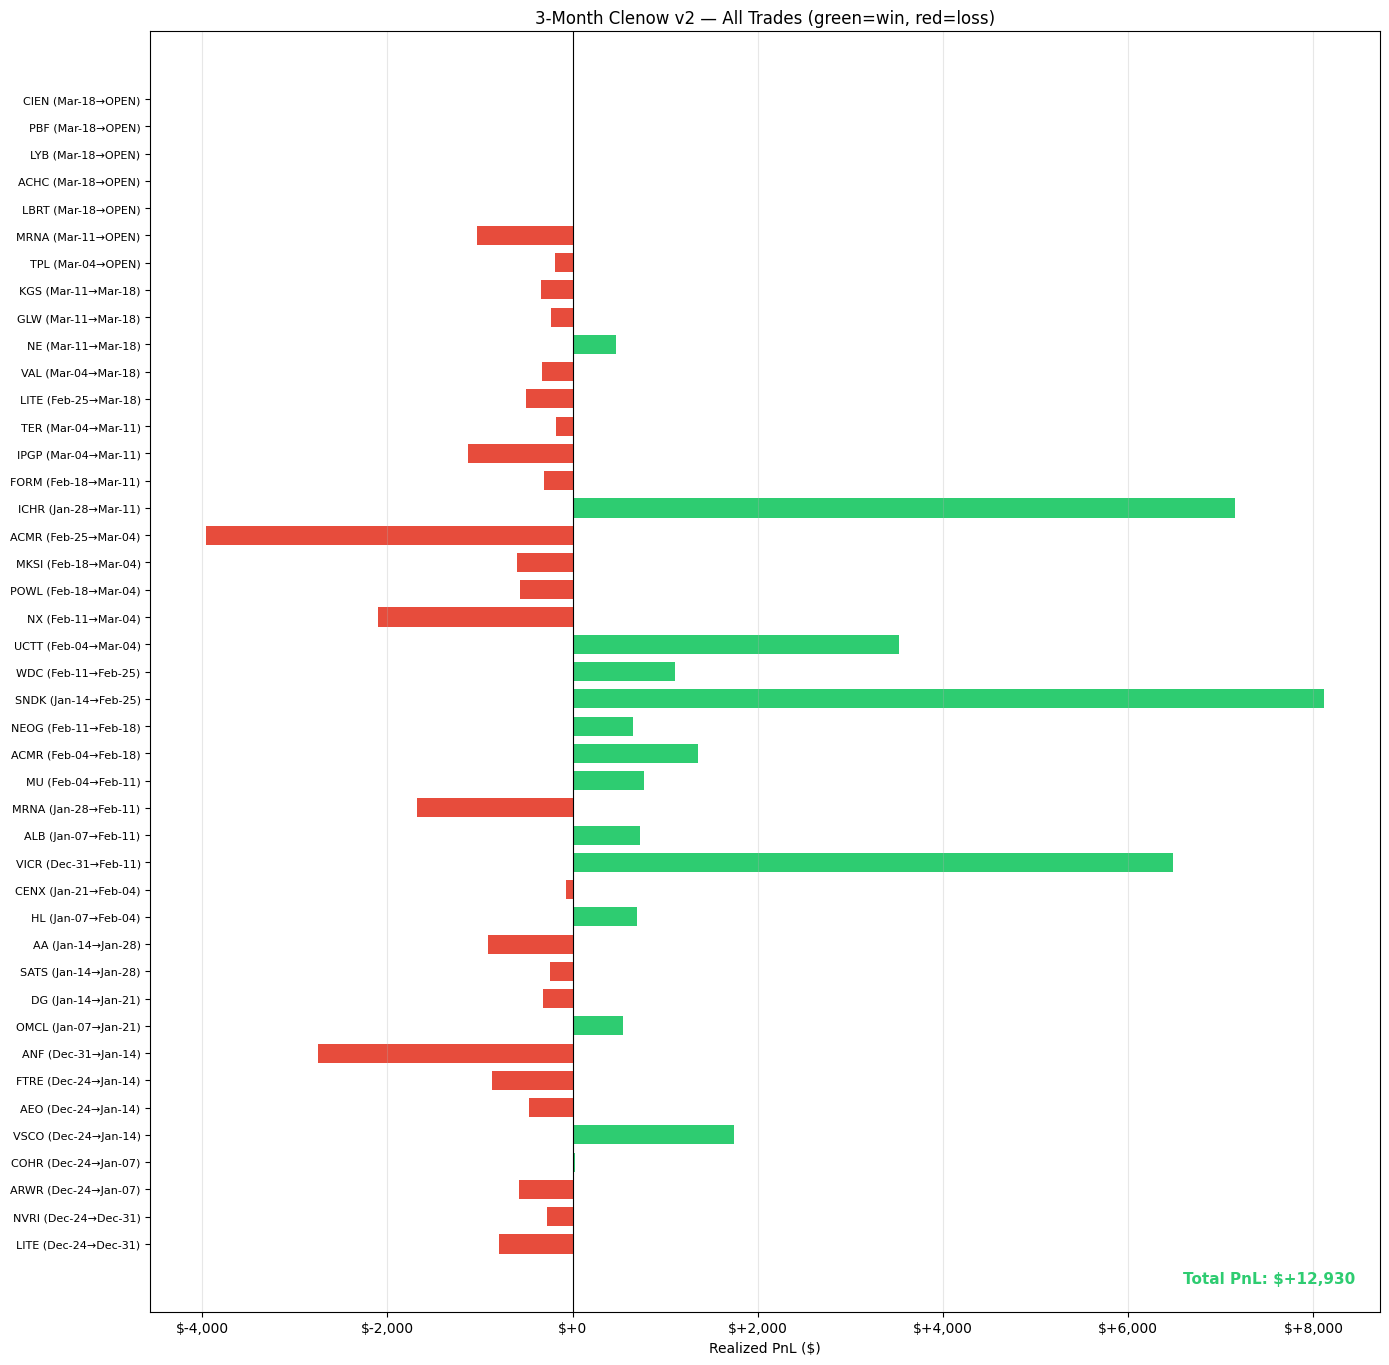

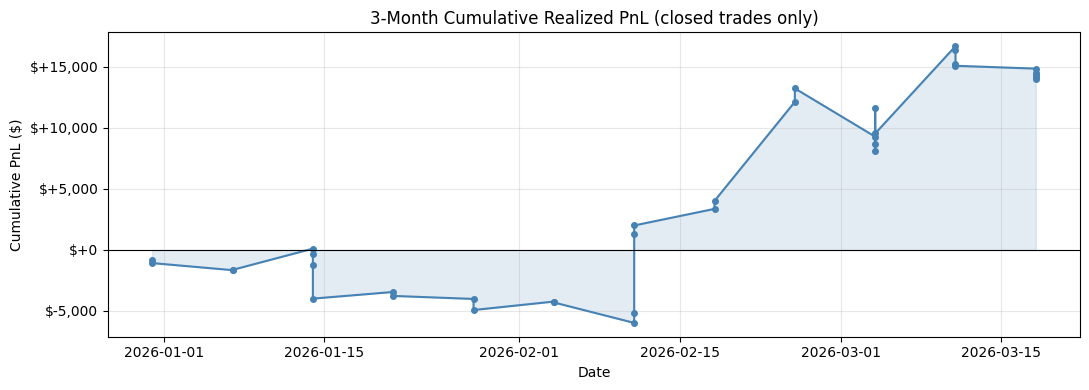

In [19]:
# ── DEEP DIVE: every single trade for the 3-month window ─────────────────────
df3m = all_results["3 Months"].copy()

# Build display table
disp = pd.DataFrame({
    "Symbol":      df3m["Symbol"],
    "Buy Date":    df3m["entry_date"].apply(lambda d: d.date()),
    "Buy $":       df3m["entry_price"].round(3),
    "Sell Date":   df3m["sell_date"],
    "Sell $":      df3m["sell_price"].round(3),
    "Invested":    df3m["notional"].map("${:,.0f}".format),
    "PnL $":       df3m["rpnl"].map("${:+,.2f}".format),
    "Return %":    df3m["ret_pct"].map("{:+.1f}%".format),
    "Hold (d)":    df3m["hold_days"],
    "Exit Reason": df3m["exit"],
    "Status":      df3m["status"],
}).sort_values(["Buy Date", "Symbol"]).reset_index(drop=True)

print(f"=== All {len(disp)} simulated Clenow trades — last 3 months ===")
print(f"    (Closed: {(disp['Status']=='CLOSED').sum()}  |  Still open: {(disp['Status']=='OPEN').sum()})\n")
display(disp)

# ── Color-coded PnL bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(5, len(disp) * 0.32)))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df3m["rpnl"]]
labels = [f"{r['Symbol']} ({r['entry_date'].strftime('%b-%d')}→"
          f"{'OPEN' if r['sell_date']=='OPEN' else pd.Timestamp(r['sell_date']).strftime('%b-%d')})"
          for _, r in df3m.iterrows()]
y_pos = range(len(df3m))
ax.barh(list(y_pos), df3m["rpnl"].values, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
ax.set_xlabel("Realized PnL ($)");  ax.set_title("3-Month Clenow v2 — All Trades (green=win, red=loss)", fontsize=12)
ax.grid(axis="x", alpha=0.3)
total3 = df3m["rpnl"].sum()
ax.text(0.98, 0.02, f"Total PnL: ${total3:+,.0f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=11, fontweight="bold",
        color="#2ecc71" if total3 > 0 else "#e74c3c")
plt.tight_layout(); plt.show()

# ── Monthly equity curve (cumulative realized) ────────────────────────────────
closed3 = df3m[df3m["status"] == "CLOSED"].copy()
if not closed3.empty:
    closed3["sell_dt"] = pd.to_datetime(closed3["sell_date"])
    closed3 = closed3.sort_values("sell_dt")
    closed3["cum_pnl"] = closed3["rpnl"].cumsum()
    fig2, ax2 = plt.subplots(figsize=(11, 4))
    ax2.plot(closed3["sell_dt"], closed3["cum_pnl"], marker="o", markersize=4,
             color="steelblue", lw=1.5)
    ax2.fill_between(closed3["sell_dt"], 0, closed3["cum_pnl"],
                     alpha=0.15, color="steelblue")
    ax2.axhline(0, color="black", lw=0.8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax2.set_title("3-Month Cumulative Realized PnL (closed trades only)", fontsize=12)
    ax2.set_xlabel("Date"); ax2.set_ylabel("Cumulative PnL ($)")
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()